# Performance Analysis

This notebook loads `perf/metrics.csv` and visualizes latency, throughput, and TTFT behavior across prompt types and concurrency levels.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics_path = Path('metrics.csv')
if not metrics_path.exists():
    metrics_path = Path('perf') / 'metrics.csv'

df = pd.read_csv(metrics_path)
df.head()

Matplotlib is building the font cache; this may take a moment.


,scenario,concurrency,prompt_type,ttft_ms,tpot,total_latency_ms
0,short_c1,1,short,1683.5479,0.593950,1683.6437
1,long_c1,1,long,128.6441,7.772804,128.6537
2,short_c4,4,short,19301.7978,0.051808,19301.9541
3,short_c4,4,short,19633.1200,0.050934,19633.2741
4,short_c4,4,short,19734.3167,0.050673,19734.4845


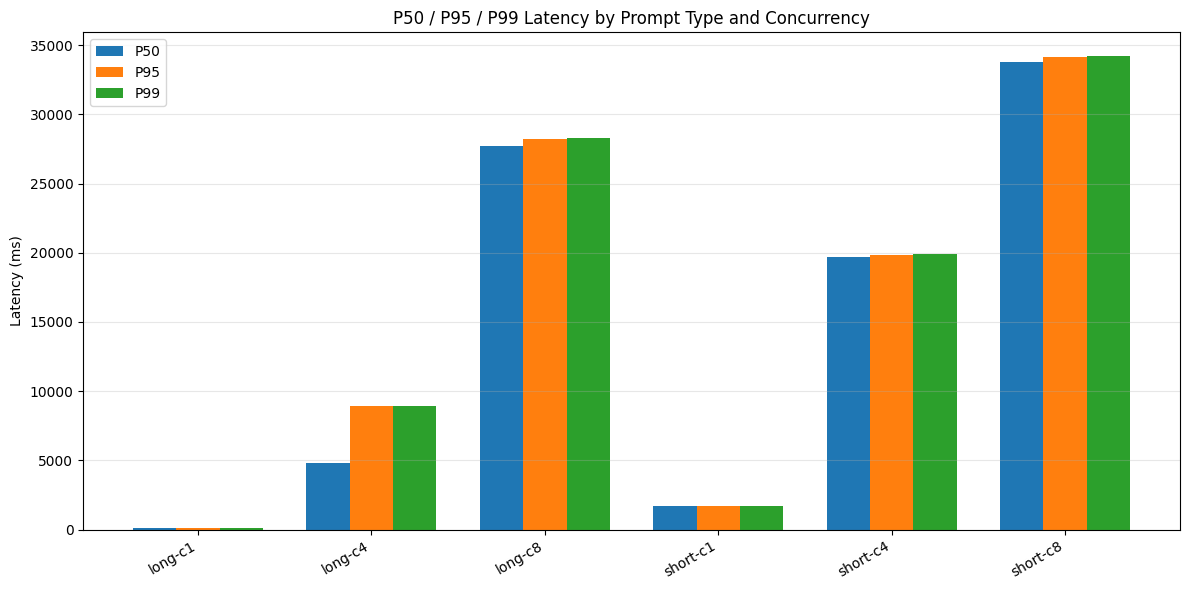

In [2]:
latency_summary = (
    df.groupby(['prompt_type', 'concurrency'])['total_latency_ms']
    .agg(
        p50=lambda values: np.percentile(values, 50),
        p95=lambda values: np.percentile(values, 95),
        p99=lambda values: np.percentile(values, 99),
    )
    .reset_index()
)

latency_summary['label'] = latency_summary['prompt_type'] + '-c' + latency_summary['concurrency'].astype(str)

x = np.arange(len(latency_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, latency_summary['p50'], width=width, label='P50')
ax.bar(x, latency_summary['p95'], width=width, label='P95')
ax.bar(x + width, latency_summary['p99'], width=width, label='P99')
ax.set_xticks(x)
ax.set_xticklabels(latency_summary['label'], rotation=30, ha='right')
ax.set_ylabel('Latency (ms)')
ax.set_title('P50 / P95 / P99 Latency by Prompt Type and Concurrency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Higher percentile latency matters more than the median when this system is exposed to real user traffic, because tail behavior determines how often users experience obvious slowness. If P95 and P99 grow much faster than P50 as concurrency increases, the service is likely saturating and queueing requests rather than scaling smoothly. In production, this usually means concurrency limits, batching strategy, or model size need to be revisited before rollout.

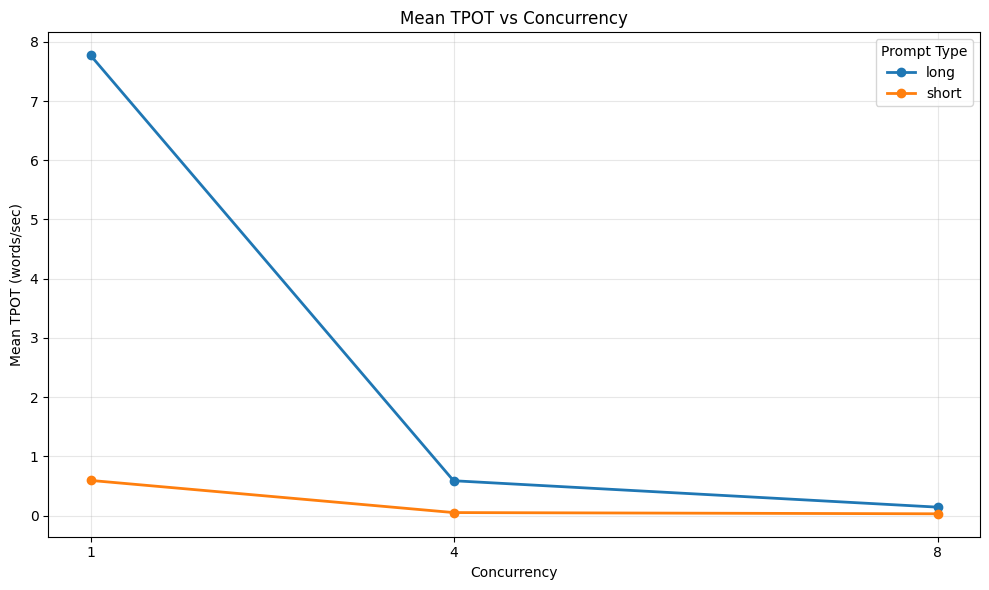

In [3]:
tpot_summary = (
    df.groupby(['prompt_type', 'concurrency'])['tpot']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
for prompt_type, group in tpot_summary.groupby('prompt_type'):
    ordered = group.sort_values('concurrency')
    ax.plot(
        ordered['concurrency'],
        ordered['tpot'],
        marker='o',
        linewidth=2,
        label=prompt_type,
    )

ax.set_xlabel('Concurrency')
ax.set_ylabel('Mean TPOT (words/sec)')
ax.set_title('Mean TPOT vs Concurrency')
ax.set_xticks(sorted(df['concurrency'].unique()))
ax.legend(title='Prompt Type')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This chart shows how efficiently the system keeps generating output as concurrency rises, which is critical for understanding whether throughput degrades under load. If long prompts lose TPOT much faster than short prompts, then prefill cost or memory pressure is probably becoming the dominant bottleneck. In production terms, that means latency-sensitive and context-heavy workloads may need different routing, autoscaling, or prompt-length controls.

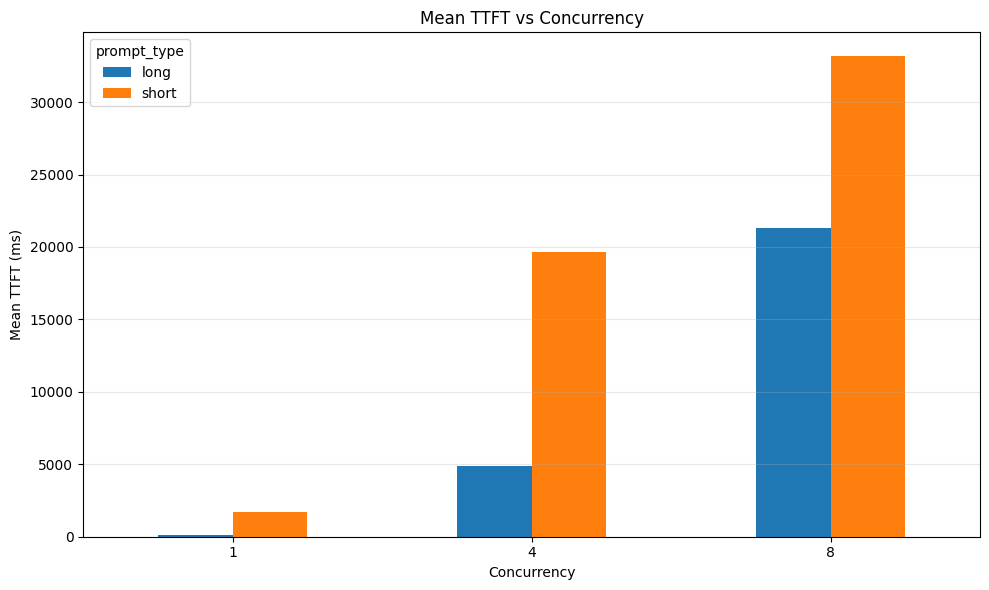

In [4]:
ttft_summary = (
    df.groupby(['prompt_type', 'concurrency'])['ttft_ms']
    .mean()
    .reset_index()
)

pivot_ttft = ttft_summary.pivot(index='concurrency', columns='prompt_type', values='ttft_ms').sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
pivot_ttft.plot(kind='bar', ax=ax)
ax.set_xlabel('Concurrency')
ax.set_ylabel('Mean TTFT (ms)')
ax.set_title('Mean TTFT vs Concurrency')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

TTFT is often the metric users feel most directly, because it captures the delay before they see any response at all. A rising TTFT curve with concurrency usually indicates scheduling, queueing, or prompt-processing overhead before generation begins, even if steady-state generation speed remains acceptable. For production scaling, this is the number that most strongly affects perceived responsiveness and should be watched alongside total latency.